In [2]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [3]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

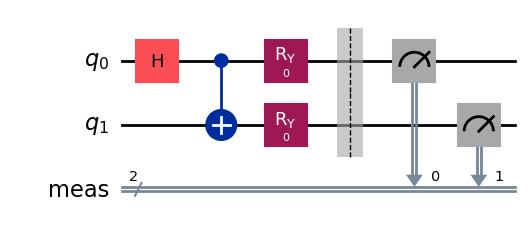

In [12]:
ntheta = 20
nchi = 20

thetas = np.linspace(0., np.pi, ntheta)
chis = np.linspace(0., np.pi, nchi)

circuits = []

for idx in np.ndindex(ntheta, nchi):
    theta = thetas[idx[0]]
    chi = chis[idx[1]]
    circuit = QuantumCircuit(2, name=f'circuit_{idx[0]}_{idx[1]}')

    circuit.h(0)
    circuit.cx(0,1)

    circuit.ry(theta,0)
    circuit.ry(chi,1)
    
    circuit.measure_all()
    circuits.append(circuit)
    
circuits[0].draw('mpl')
#circuits[1].draw('mpl')
